In [64]:
import pandas as pd
import seaborn as sns


In [65]:
tips=sns.load_dataset('tips')

In [66]:
tips.head() 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [67]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [68]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [69]:
print(tips['day'].unique())
print(tips['sex'].unique())
print(tips['size'].unique())
print(tips['smoker'].unique())
print(tips['time'].unique())


['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
['Female', 'Male']
Categories (2, object): ['Male', 'Female']
[2 3 4 1 6 5]
['No', 'Yes']
Categories (2, object): ['Yes', 'No']
['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']


In [70]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

There is no null value present in the data.

In [71]:
tips.sample(10)

,total_bill,tip,sex,smoker,day,time,size
225,16.27,2.50,Female,Yes,Fri,Lunch,2
11,35.26,5.00,Female,No,Sun,Dinner,4
168,10.59,1.61,Female,Yes,Sat,Dinner,2
187,30.46,2.00,Male,Yes,Sun,Dinner,5
18,16.97,3.50,Female,No,Sun,Dinner,3
135,8.51,1.25,Female,No,Thur,Lunch,2
149,7.51,2.00,Male,No,Thur,Lunch,2
233,10.77,1.47,Male,No,Sat,Dinner,2
61,13.81,2.00,Male,Yes,Sat,Dinner,2
75,10.51,1.25,Male,No,Sat,Dinner,2


Univariate and Multivariate Analysis

<Axes: xlabel='count', ylabel='day'>

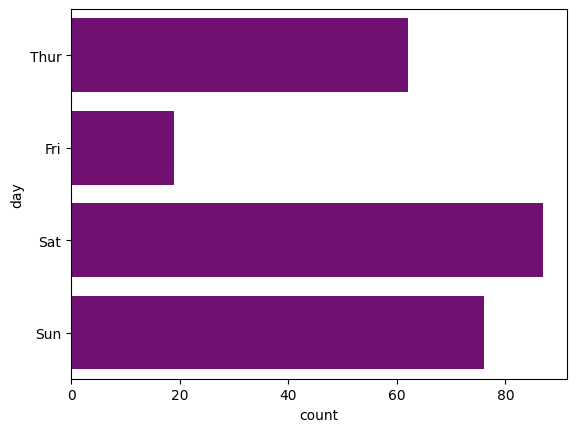

In [72]:
sns.countplot(tips['day'],color='purple') 

Most of the visiting are on Saturday.

<Axes: xlabel='count', ylabel='smoker'>

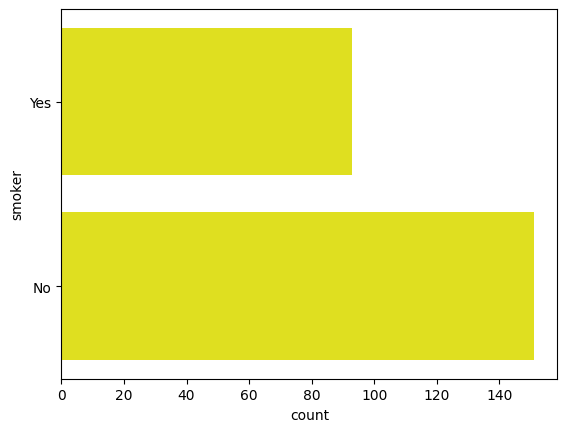

In [73]:
sns.countplot(tips['smoker'],color='yellow') 

It's good that the number of visitors are high in non-smoking category.  

<Axes: xlabel='count', ylabel='sex'>

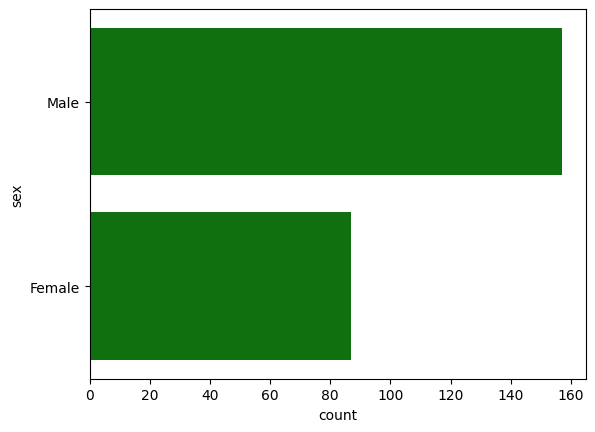

In [74]:
sns.countplot(tips['sex'],color='green') 

Males are visiting more than females.

<Axes: xlabel='size', ylabel='count'>

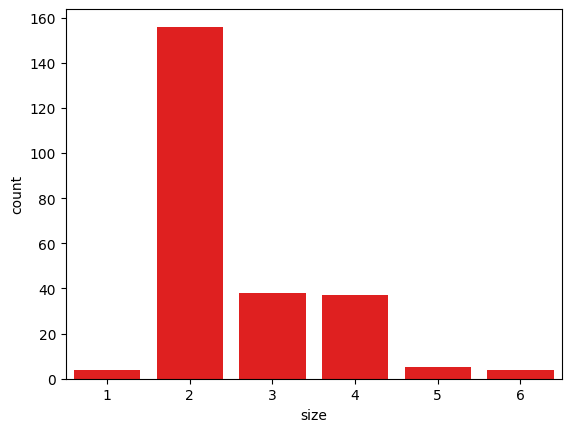

In [75]:
sns.countplot(tips,x='size',color='red') 

The group of 2 people are visiting more than any other groups.

<Axes: ylabel='count'>

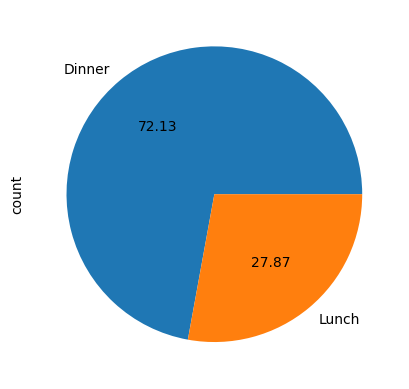

In [76]:
tips['time'].value_counts().plot(kind='pie',autopct='%.2f')

Most of the people visit for dinner.

# Comparison between datasets.

total_bill vs. tips

<Axes: xlabel='total_bill', ylabel='tip'>

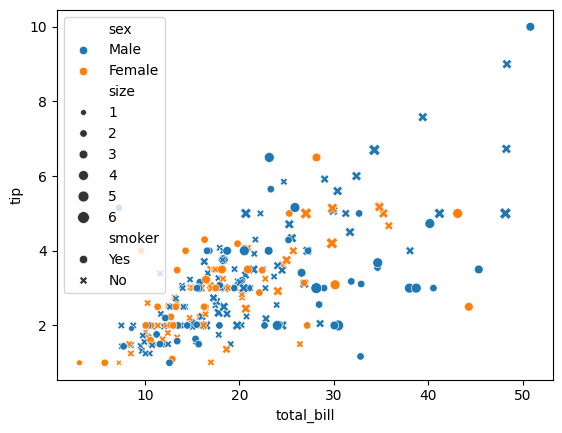

In [77]:
sns.scatterplot(tips,x='total_bill',y='tip',hue='sex',style='smoker',size='size')

The most frequent total_bill with its tip are belonging to 12-24 something and tips ranging from 2-4.

<Axes: xlabel='sex', ylabel='smoker'>

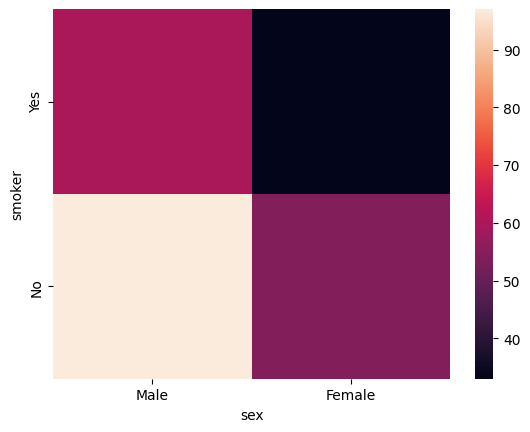

In [78]:
sns.heatmap(pd.crosstab(tips['smoker'],tips['sex']))

<Axes: xlabel='smoker', ylabel='count'>

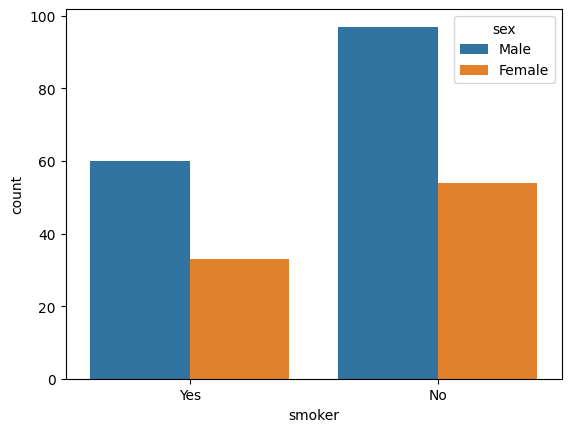

In [79]:
sns.countplot(tips,x='smoker',hue='sex') 

In [80]:
pd.crosstab(tips['sex'],tips['smoker']) 

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


From the graph as well as from the pd table the number of male smokers are more than the number of female smokers.

sex vs. tip

In [81]:
# tips.loc[tips['tip'].idxmax(),['sex','tip']]

tips.groupby('sex')['tip'].sum()


C:\Users\welcome\AppData\Local\Temp\ipykernel_14080\1840077613.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('sex')['tip'].sum()


sex
Male      485.07
Female    246.51
Name: tip, dtype: float64

<Axes: xlabel='sex', ylabel='tip'>

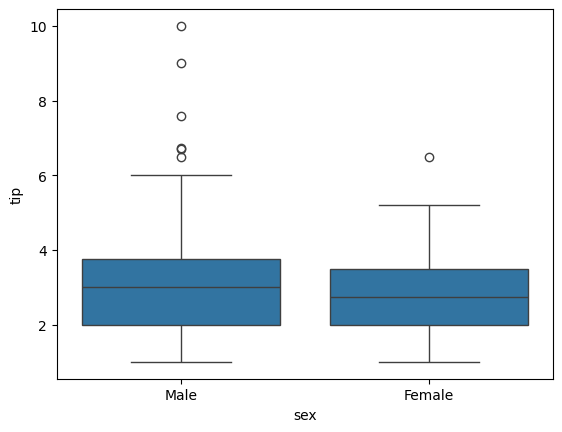

In [82]:
sns.boxplot(tips,x='sex',y='tip')

The male are giving more tip than females.

<Axes: xlabel='sex', ylabel='count'>

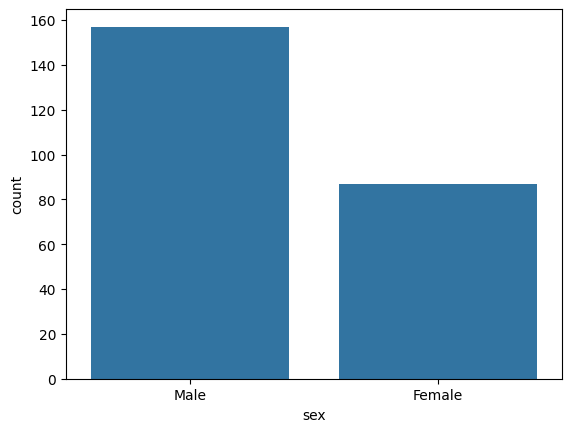

In [83]:
sns.barplot(tips['sex'].value_counts())

Males are visiting more than females

day vs. time

In [84]:
pd.crosstab(tips['day'],tips['time'])

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


<Axes: xlabel='time', ylabel='day'>

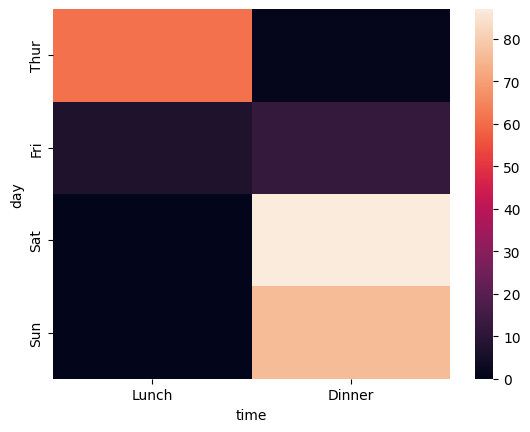

In [85]:
sns.heatmap(pd.crosstab(tips['day'],tips['time']))


On Thursday the resto or whatever it is is having the most of the crowd while on the Saturday and Sunday the resto is full of crowd during the dinner time.

time vs. size

In [86]:
tips.groupby('time')['size'].count() 

C:\Users\welcome\AppData\Local\Temp\ipykernel_14080\3158711143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('time')['size'].count()


time
Lunch      68
Dinner    176
Name: size, dtype: int64

The people are visiting more during dinner time.

Feature Engineering

In [87]:
def size(number):
    if number==0:
        return 'Alone'
    elif number>2 & number <5:
        return 'Medium'
    else:
        return 'Large'


In [88]:
tips['size_type']=tips['size'].apply(size)

In [89]:
tips.sample(5)


,total_bill,tip,sex,smoker,day,time,size,size_type
99,12.46,1.50,Male,No,Fri,Dinner,2,Large
80,19.44,3.00,Male,Yes,Thur,Lunch,2,Large
179,34.63,3.55,Male,Yes,Sun,Dinner,2,Large
233,10.77,1.47,Male,No,Sat,Dinner,2,Large
182,45.35,3.50,Male,Yes,Sun,Dinner,3,Medium


Detecting Outliers and Removing them.

Size

<Axes: xlabel='size'>

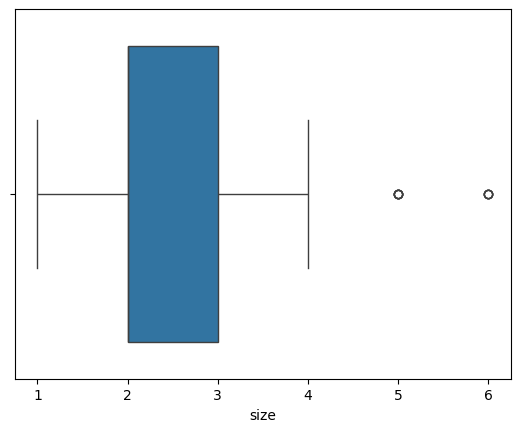

In [90]:
sns.boxplot(tips,x='size')

In [91]:
import numpy as np

q1=np.percentile(tips['size'],25)
q3=np.percentile(tips['size'],75)
iqr=q3-q1


lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

tip_size=tips[(tips['size']>lower_bound) & (tips['size']<upper_bound)]

tip_size


,total_bill,tip,sex,smoker,day,time,size,size_type
0,16.99,1.01,Female,No,Sun,Dinner,2,Large
1,10.34,1.66,Male,No,Sun,Dinner,3,Medium
2,21.01,3.50,Male,No,Sun,Dinner,3,Medium
3,23.68,3.31,Male,No,Sun,Dinner,2,Large
4,24.59,3.61,Female,No,Sun,Dinner,4,Medium
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,Medium
240,27.18,2.00,Female,Yes,Sat,Dinner,2,Large
241,22.67,2.00,Male,Yes,Sat,Dinner,2,Large
242,17.82,1.75,Male,No,Sat,Dinner,2,Large
